# Black-Scholes: From Model to PnL

This notebook walks through the complete hedging workflow: pricing an option, computing Greeks, delta-hedging, and decomposing the resulting PnL into its components.

We'll see that Black-Scholes isn't really about the formula—it's about the replicating portfolio. The price is just the cost of setting up the hedge. Along the way, we'll understand gamma bleeding, the gamma-theta tradeoff, and how to detect when your model is failing you.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

np.random.seed(42)

## 1. Black-Scholes Pricing and Greeks

The Black-Scholes price for a European call:

$$C(S, t) = S\Phi(d_1) - Ke^{-r\tau}\Phi(d_2)$$

where $\tau = T - t$ and:

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)\tau}{\sigma\sqrt{\tau}}, \quad d_2 = d_1 - \sigma\sqrt{\tau}$$

The Greeks measure sensitivity to each input. For a call:

- $\Delta = \Phi(d_1)$
- $\Gamma = \phi(d_1)/(S\sigma\sqrt{\tau})$
- $\Theta = -S\phi(d_1)\sigma/(2\sqrt{\tau}) - rKe^{-r\tau}\Phi(d_2)$
- $\mathcal{V} = S\phi(d_1)\sqrt{\tau}$

In [18]:
def bs_price(S, K, tau, r, sigma, option_type='call'):
    if tau <= 0:
        if option_type == 'call':
            return max(S - K, 0)
        else:
            return max(K - S, 0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    else:
        return K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)


def bs_greeks(S, K, tau, r, sigma, option_type='call'):
    """Compute all Greeks for Black-Scholes."""
    if tau <= 0:
        price = max(S - K, 0) if option_type == 'call' else max(K - S, 0)
        delta = 1.0 if (option_type == 'call' and S > K) else (-1.0 if (option_type == 'put' and S < K) else 0.0)
        return {'price': price, 'delta': delta, 'gamma': 0, 'theta': 0, 'vega': 0, 'rho': 0}
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    
    phi_d1 = norm.pdf(d1)  # Standard normal PDF
    Phi_d1 = norm.cdf(d1)  # Standard normal CDF
    Phi_d2 = norm.cdf(d2)
    
    # Common calculations
    gamma = phi_d1 / (S * sigma * np.sqrt(tau))
    vega = S * phi_d1 * np.sqrt(tau)
    
    if option_type == 'call':
        price = S * Phi_d1 - K * np.exp(-r * tau) * Phi_d2
        delta = Phi_d1
        theta = -S * phi_d1 * sigma / (2 * np.sqrt(tau)) - r * K * np.exp(-r * tau) * Phi_d2
        rho = K * tau * np.exp(-r * tau) * Phi_d2
    else:
        price = K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = -norm.cdf(-d1)
        theta = -S * phi_d1 * sigma / (2 * np.sqrt(tau)) + r * K * np.exp(-r * tau) * norm.cdf(-d2)
        rho = -K * tau * np.exp(-r * tau) * norm.cdf(-d2)
    
    return {
        'price': price,
        'delta': delta,
        'gamma': gamma,
        'theta': theta,
        'vega': vega,
        'rho': rho
    }

In [19]:
# Test the Greeks calculation
S0, K, T, r, sigma = 100, 100, 0.25, 0.05, 0.20

greeks = bs_greeks(S0, K, T, r, sigma, 'call')
print("ATM Call Option Greeks (S=K=100, T=0.25, sigma=20%)")
print("="*50)
for name, value in greeks.items():
    print(f"{name.capitalize():8s}: {value:10.6f}")

ATM Call Option Greeks (S=K=100, T=0.25, sigma=20%)
Price   :   4.614997
Delta   :   0.569460
Gamma   :   0.039288
Theta   : -10.474151
Vega    :  19.644000
Rho     :  13.082755


## 2. The Replicating Portfolio

Black-Scholes is fundamentally a statement about replication: a European option can be perfectly replicated by continuously trading $\Delta_t$ shares of stock and borrowing/lending at the risk-free rate.

The self-financing portfolio $\Pi_t = \Delta_t S_t + B_t$ satisfies:

$$d\Pi_t = \Delta_t \, dS_t + r B_t \, dt$$

Hedging continuously with the BS delta, the portfolio tracks the option value exactly. We simulate this below to see how well it works in practice.

In [20]:
def simulate_gbm_path(S0, r, sigma, T, n_steps):
    """Simulate a single GBM path under risk-neutral measure."""
    dt = T / n_steps
    times = np.linspace(0, T, n_steps + 1)
    
    # Generate increments
    dW = np.random.randn(n_steps) * np.sqrt(dt)
    
    # Construct path
    log_returns = (r - 0.5 * sigma**2) * dt + sigma * dW
    prices = S0 * np.exp(np.concatenate([[0], np.cumsum(log_returns)]))
    
    return times, prices

In [21]:
def delta_hedge_simulation(S0, K, T, r, sigma, n_hedge_times, option_type='call'):
    """ Simulate delta-hedging a short option position.
    We sell an option at t=0 and delta-hedge until expiry.
    """
    dt = T / n_hedge_times
    
    # Simulate stock path (use many substeps for accuracy)
    n_substeps = max(1000, n_hedge_times * 10)
    times_fine, prices_fine = simulate_gbm_path(S0, r, sigma, T, n_substeps)
    
    # Extract prices at hedge times
    hedge_indices = np.linspace(0, n_substeps, n_hedge_times + 1, dtype=int)
    times = times_fine[hedge_indices]
    S = prices_fine[hedge_indices]
    
    # Initial option price (what we receive for selling)
    V0 = bs_price(S0, K, T, r, sigma, option_type)
    
    # Initialize hedge portfolio
    # We are SHORT the option, so we receive V0 and must replicate -V
    greeks_0 = bs_greeks(S0, K, T, r, sigma, option_type)
    delta = greeks_0['delta']
    
    # Portfolio: delta shares + cash
    shares = delta
    cash = V0 - delta * S0  # After buying delta shares
    
    # Track everything
    portfolio_values = [V0]
    option_values = [V0]
    deltas = [delta]
    cash_positions = [cash]
    share_positions = [shares]
    
    # Step through time
    for i in range(1, n_hedge_times + 1):
        tau = T - times[i]  # Time remaining
        
        # Cash grows at risk-free rate
        cash *= np.exp(r * dt)
        
        # Current portfolio value (before rebalancing)
        portfolio_value = shares * S[i] + cash
        
        # Current option value
        option_value = bs_price(S[i], K, tau, r, sigma, option_type)
        
        # New delta
        if tau > 0:
            new_greeks = bs_greeks(S[i], K, tau, r, sigma, option_type)
            new_delta = new_greeks['delta']
        else:
            new_delta = 1.0 if (option_type == 'call' and S[i] > K) else 0.0
        
        # Rebalance: buy/sell shares to match new delta
        shares_traded = new_delta - shares
        cash -= shares_traded * S[i]  # Pay for shares
        shares = new_delta
        
        # Store
        portfolio_values.append(portfolio_value)
        option_values.append(option_value)
        deltas.append(new_delta)
        cash_positions.append(cash)
        share_positions.append(shares)
    
    # Final PnL: Portfolio value - Option payoff we must pay
    if option_type == 'call':
        payoff = max(S[-1] - K, 0)
    else:
        payoff = max(K - S[-1], 0)
    
    final_portfolio = shares * S[-1] + cash
    hedge_pnl = final_portfolio - payoff
    
    return {
        'times': times,
        'spot': S,
        'portfolio_values': np.array(portfolio_values),
        'option_values': np.array(option_values),
        'deltas': np.array(deltas),
        'hedge_pnl': hedge_pnl,
        'payoff': payoff,
        'final_portfolio': final_portfolio
    }

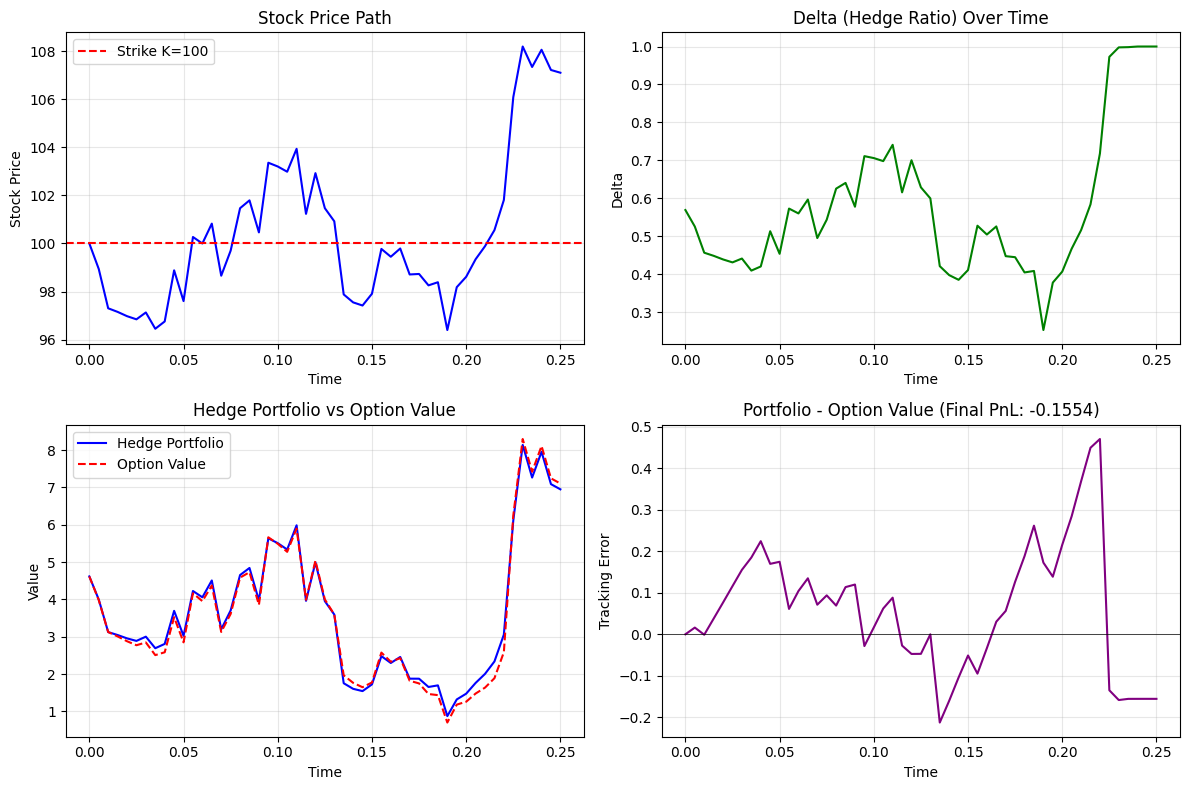


Final Results:
  Option Payoff:     7.1043
  Portfolio Value:   6.9489
  Hedge PnL:         -0.1554


In [22]:
# Demonstrate on a single path
S0, K, T, r, sigma = 100, 100, 0.25, 0.05, 0.20

result = delta_hedge_simulation(S0, K, T, r, sigma, n_hedge_times=50, option_type='call')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Stock price path
axes[0, 0].plot(result['times'], result['spot'], 'b-', linewidth=1.5)
axes[0, 0].axhline(K, color='r', linestyle='--', label=f'Strike K={K}')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Stock Price')
axes[0, 0].set_title('Stock Price Path')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Delta over time
axes[0, 1].plot(result['times'], result['deltas'], 'g-', linewidth=1.5)
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Delta')
axes[0, 1].set_title('Delta (Hedge Ratio) Over Time')
axes[0, 1].grid(True, alpha=0.3)

# Portfolio vs Option value
axes[1, 0].plot(result['times'], result['portfolio_values'], 'b-', label='Hedge Portfolio', linewidth=1.5)
axes[1, 0].plot(result['times'], result['option_values'], 'r--', label='Option Value', linewidth=1.5)
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Value')
axes[1, 0].set_title('Hedge Portfolio vs Option Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Tracking error
tracking_error = result['portfolio_values'] - result['option_values']
axes[1, 1].plot(result['times'], tracking_error, 'purple', linewidth=1.5)
axes[1, 1].axhline(0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Tracking Error')
axes[1, 1].set_title(f'Portfolio - Option Value (Final PnL: {result["hedge_pnl"]:.4f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Option Payoff:     {result['payoff']:.4f}")
print(f"  Portfolio Value:   {result['final_portfolio']:.4f}")
print(f"  Hedge PnL:         {result['hedge_pnl']:.4f}")

## 3. Discrete Hedging and Gamma Bleeding

In practice we can't hedge continuously—this creates hedging error.

From the Taylor expansion of option value:

$$dV \approx \Delta \, dS + \frac{1}{2}\Gamma (dS)^2 + \Theta \, dt + \mathcal{V} \, d\sigma$$

A delta-hedged portfolio has PnL:

$$d\Pi_{\text{hedged}} = \frac{1}{2}\Gamma (dS)^2 + \Theta \, dt$$

Under continuous hedging, the gamma and theta terms exactly offset (the BS PDE). But with discrete hedging, $(dS)^2 \neq \sigma^2 S^2 dt$ on any given path—realized variance differs from implied. This mismatch creates what traders call "gamma bleeding."

The standard deviation of discrete hedging PnL scales as $O(1/\sqrt{n})$ where $n$ is the number of rebalances.

In [23]:
def analyze_hedge_frequency(S0, K, T, r, sigma, n_paths, hedge_frequencies, option_type='call'):
    """Analyze how hedging frequency affects PnL distribution."""
    results = []
    pnl_distributions = {}
    
    for n_hedge in hedge_frequencies:
        pnls = []
        for _ in range(n_paths):
            sim = delta_hedge_simulation(S0, K, T, r, sigma, n_hedge, option_type)
            pnls.append(sim['hedge_pnl'])
        
        pnls = np.array(pnls)
        pnl_distributions[n_hedge] = pnls
        
        results.append({
            'n_rebalances': n_hedge,
            'mean_pnl': np.mean(pnls),
            'std_pnl': np.std(pnls),
            'min_pnl': np.min(pnls),
            'max_pnl': np.max(pnls),
            '5th_percentile': np.percentile(pnls, 5),
            '95th_percentile': np.percentile(pnls, 95)
        })
    
    return pd.DataFrame(results), pnl_distributions

In [24]:
# Analyze different hedging frequencies
S0, K, T, r, sigma = 100, 100, 0.25, 0.05, 0.20
n_paths = 1000
hedge_frequencies = [5, 10, 25, 50, 100, 250]

print("Running hedge frequency analysis...")
df_freq, pnl_dists = analyze_hedge_frequency(S0, K, T, r, sigma, n_paths, hedge_frequencies)

print("\nHedge Frequency Analysis Results:")
print("="*80)
print(df_freq.to_string(index=False, float_format='{:.6f}'.format))

Running hedge frequency analysis...

Hedge Frequency Analysis Results:
 n_rebalances  mean_pnl  std_pnl   min_pnl  max_pnl  5th_percentile  95th_percentile
            5 -0.027846 1.442597 -5.942480 3.528516       -2.453025         2.265067
           10  0.033356 0.993593 -5.231665 3.047115       -1.609889         1.670701
           25 -0.004569 0.702782 -3.482389 2.371135       -1.141420         1.142473
           50  0.027501 0.491939 -3.283649 1.594189       -0.722729         0.824518
          100  0.013918 0.333773 -1.177576 1.333243       -0.525763         0.586319
          250 -0.005667 0.215202 -0.767826 1.051794       -0.362133         0.336460


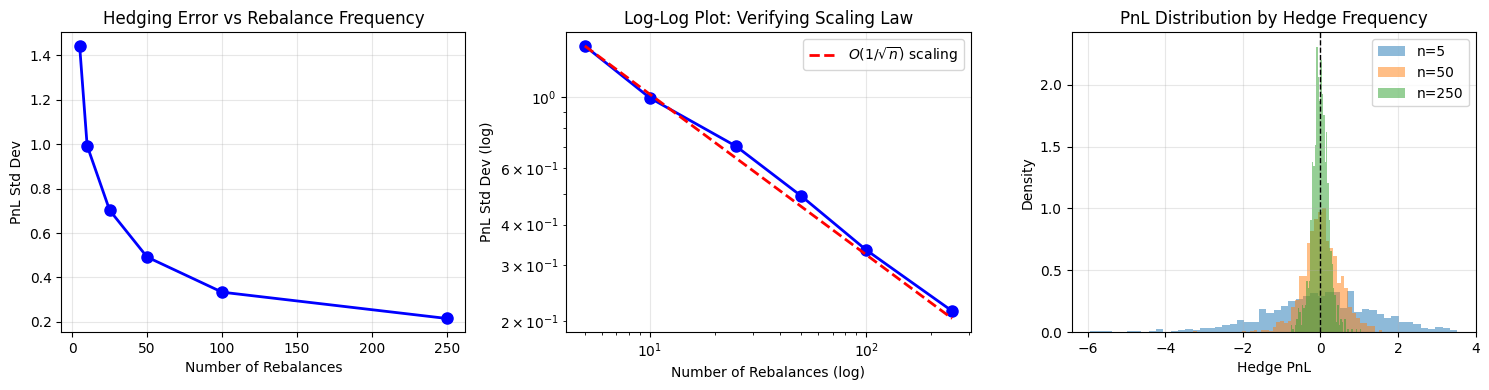

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PnL Standard Deviation vs Hedge Frequency
axes[0].plot(df_freq['n_rebalances'], df_freq['std_pnl'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Rebalances')
axes[0].set_ylabel('PnL Std Dev')
axes[0].set_title('Hedging Error vs Rebalance Frequency')
axes[0].grid(True, alpha=0.3)

# Log-log plot to verify O(1/sqrt(n)) scaling
axes[1].loglog(df_freq['n_rebalances'], df_freq['std_pnl'], 'bo-', linewidth=2, markersize=8)
# Add reference line for 1/sqrt(n) scaling
n_ref = np.array(hedge_frequencies)
scaling = df_freq['std_pnl'].iloc[0] * np.sqrt(hedge_frequencies[0]) / np.sqrt(n_ref)
axes[1].loglog(n_ref, scaling, 'r--', linewidth=2, label=r'$O(1/\sqrt{n})$ scaling')
axes[1].set_xlabel('Number of Rebalances (log)')
axes[1].set_ylabel('PnL Std Dev (log)')
axes[1].set_title('Log-Log Plot: Verifying Scaling Law')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PnL Distributions
for n_hedge in [5, 50, 250]:
    axes[2].hist(pnl_dists[n_hedge], bins=50, alpha=0.5, label=f'n={n_hedge}', density=True)
axes[2].axvline(0, color='k', linestyle='--', linewidth=1)
axes[2].set_xlabel('Hedge PnL')
axes[2].set_ylabel('Density')
axes[2].set_title('PnL Distribution by Hedge Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The plots confirm what theory predicts: mean PnL is roughly zero (no free lunch), but the standard deviation decreases with hedging frequency. The distribution is symmetric—gains and losses equally likely.

This is the cost of discrete hedging. If you think realized vol will exceed implied, you want to be long gamma. If you think realized will be lower, short gamma is the play.

## 4. PnL Attribution

Every trading desk decomposes daily PnL into Greek components:

$$\Delta\text{PnL} = \underbrace{\Delta \cdot \Delta S}_{\text{delta}} + \underbrace{\frac{1}{2}\Gamma \cdot (\Delta S)^2}_{\text{gamma}} + \underbrace{\Theta \cdot \Delta t}_{\text{theta}} + \underbrace{\mathcal{V} \cdot \Delta\sigma}_{\text{vega}} + \underbrace{\epsilon}_{\text{unexplained}}$$

The unexplained residual is the key diagnostic. If it's systematically nonzero, your model is missing something. If it's random noise around zero, your model is capturing the main effects.

In [26]:
def pnl_attribution(V_t, V_t1, greeks_t, S_t, S_t1, sigma_t, sigma_t1, dt):
    actual_pnl = V_t1 - V_t
    dS = S_t1 - S_t
    d_sigma = sigma_t1 - sigma_t
    
    delta_pnl = greeks_t['delta'] * dS
    gamma_pnl = 0.5 * greeks_t['gamma'] * dS**2
    theta_pnl = greeks_t['theta'] * dt
    vega_pnl = greeks_t['vega'] * d_sigma
    
    explained_pnl = delta_pnl + gamma_pnl + theta_pnl + vega_pnl
    unexplained = actual_pnl - explained_pnl
    
    return {
        'actual': actual_pnl,
        'delta': delta_pnl,
        'gamma': gamma_pnl,
        'theta': theta_pnl,
        'vega': vega_pnl,
        'explained': explained_pnl,
        'unexplained': unexplained
    }

In [27]:
def simulate_with_pnl_attribution(S0, K, T, r, sigma, n_steps, option_type='call'):
    """Simulate a path and compute full PnL attribution at each step."""
    dt = T / n_steps
    times, prices = simulate_gbm_path(S0, r, sigma, T, n_steps)
    
    # Store attribution at each step
    attributions = []
    
    for i in range(n_steps):
        tau_t = T - times[i]
        tau_t1 = T - times[i+1]
        
        # Get option values and Greeks
        greeks_t = bs_greeks(prices[i], K, tau_t, r, sigma, option_type)
        V_t = greeks_t['price']
        V_t1 = bs_price(prices[i+1], K, tau_t1, r, sigma, option_type)
        
        # Attribute PnL (constant vol assumption)
        attr = pnl_attribution(V_t, V_t1, greeks_t, prices[i], prices[i+1], sigma, sigma, dt)
        attr['time'] = times[i]
        attr['spot'] = prices[i]
        attributions.append(attr)
    
    return pd.DataFrame(attributions), times, prices

In [28]:
# Run PnL attribution simulation
S0, K, T, r, sigma = 100, 100, 0.25, 0.05, 0.20
n_steps = 63  # Daily for a quarter

attr_df, times, prices = simulate_with_pnl_attribution(S0, K, T, r, sigma, n_steps, 'call')

# Summary statistics
print("PnL Attribution Summary (summed over path):")
print("="*50)
components = ['delta', 'gamma', 'theta', 'vega', 'unexplained', 'actual']
for comp in components:
    total = attr_df[comp].sum()
    print(f"{comp.capitalize():12s}: {total:10.6f}")

print(f"\nExplained %: {100 * attr_df['explained'].sum() / attr_df['actual'].sum():.2f}%")

PnL Attribution Summary (summed over path):
Delta       :  -4.630153
Gamma       :   1.072117
Theta       :  -1.078983
Vega        :   0.000000
Unexplained :   0.022022
Actual      :  -4.614997

Explained %: 100.48%


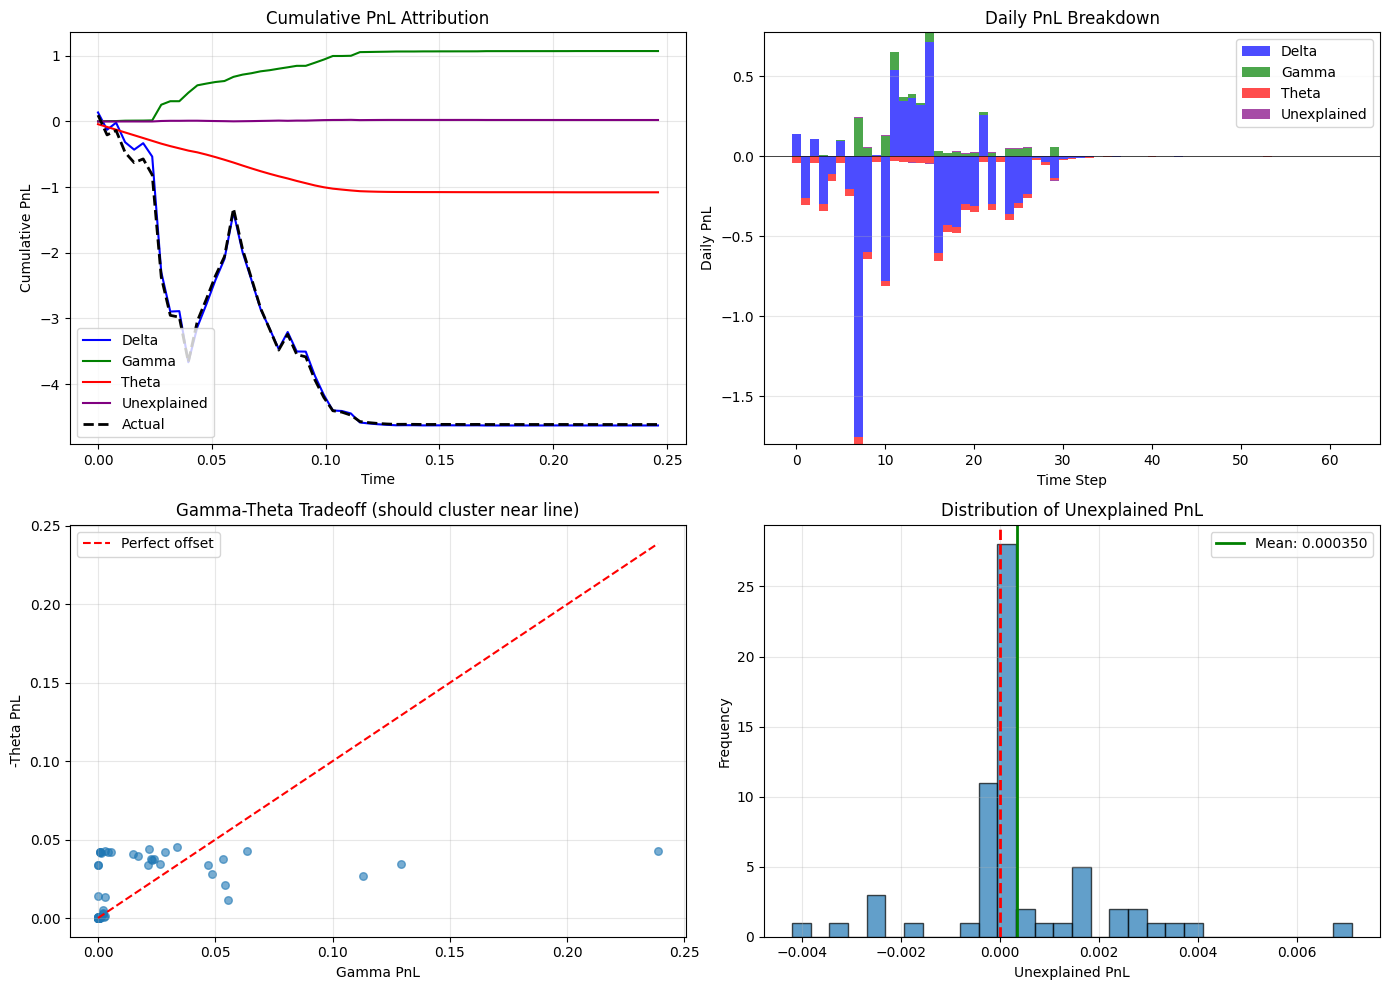

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cumulative PnL by component
ax = axes[0, 0]
for comp, color in [('delta', 'blue'), ('gamma', 'green'), ('theta', 'red'), ('unexplained', 'purple')]:
    ax.plot(attr_df['time'], attr_df[comp].cumsum(), label=comp.capitalize(), linewidth=1.5, color=color)
ax.plot(attr_df['time'], attr_df['actual'].cumsum(), 'k--', label='Actual', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative PnL')
ax.set_title('Cumulative PnL Attribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Stacked bar chart of daily attribution
ax = axes[0, 1]
bottom_pos = np.zeros(len(attr_df))
bottom_neg = np.zeros(len(attr_df))
colors = {'delta': 'blue', 'gamma': 'green', 'theta': 'red', 'unexplained': 'purple'}

for comp in ['delta', 'gamma', 'theta', 'unexplained']:
    values = attr_df[comp].values
    pos_vals = np.where(values > 0, values, 0)
    neg_vals = np.where(values < 0, values, 0)
    ax.bar(range(len(attr_df)), pos_vals, bottom=bottom_pos, label=comp.capitalize(), color=colors[comp], alpha=0.7, width=1)
    ax.bar(range(len(attr_df)), neg_vals, bottom=bottom_neg, color=colors[comp], alpha=0.7, width=1)
    bottom_pos += pos_vals
    bottom_neg += neg_vals

ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Time Step')
ax.set_ylabel('Daily PnL')
ax.set_title('Daily PnL Breakdown')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Gamma vs Theta relationship
ax = axes[1, 0]
ax.scatter(attr_df['gamma'], -attr_df['theta'], alpha=0.6, s=30)
ax.plot([attr_df['gamma'].min(), attr_df['gamma'].max()], 
        [attr_df['gamma'].min(), attr_df['gamma'].max()], 'r--', label='Perfect offset')
ax.set_xlabel('Gamma PnL')
ax.set_ylabel('-Theta PnL')
ax.set_title('Gamma-Theta Tradeoff (should cluster near line)')
ax.legend()
ax.grid(True, alpha=0.3)

# Unexplained PnL distribution
ax = axes[1, 1]
ax.hist(attr_df['unexplained'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='r', linestyle='--', linewidth=2)
ax.axvline(attr_df['unexplained'].mean(), color='g', linestyle='-', linewidth=2, label=f"Mean: {attr_df['unexplained'].mean():.6f}")
ax.set_xlabel('Unexplained PnL')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Unexplained PnL')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The gamma-theta scatter plot shows the fundamental tradeoff: long gamma means you profit from big moves, but you pay theta every day. Under Black-Scholes with realized vol matching implied, these two effects should cancel out on average.

When they don't cancel:
- Realized vol > implied vol → gamma PnL exceeds theta cost → long gamma wins
- Realized vol < implied vol → theta cost exceeds gamma PnL → short gamma wins

This is the basis of volatility trading.

## 5. Detecting Model Failure

The unexplained PnL should be mean-zero and randomly distributed. When it's systematically positive or negative, your model is missing something important.

Let's see what happens when we hedge with one volatility but the stock actually moves with a different realized volatility.

In [30]:
def simulate_model_mismatch(S0, K, T, r, sigma_model, sigma_realized, n_steps, n_paths, option_type='call'):
    """ Simulate when realized volatility differs from model volatility.
    - Price and hedge using sigma_model
    - Stock actually moves with sigma_realized
    """
    dt = T / n_steps
    all_unexplained = []
    all_gamma_pnl = []
    all_theta_pnl = []
    hedge_pnls = []
    
    for _ in range(n_paths):
        # Simulate with REALIZED vol
        times, prices = simulate_gbm_path(S0, r, sigma_realized, T, n_steps)
        
        path_unexplained = []
        path_gamma = []
        path_theta = []
        
        for i in range(n_steps):
            tau_t = T - times[i]
            tau_t1 = T - times[i+1]
            
            # Greeks computed with MODEL vol
            greeks_t = bs_greeks(prices[i], K, tau_t, r, sigma_model, option_type)
            
            # Actual option value (priced with model vol, but stock moved with realized vol)
            V_t = greeks_t['price']
            V_t1 = bs_price(prices[i+1], K, tau_t1, r, sigma_model, option_type)
            
            # Attribution
            attr = pnl_attribution(V_t, V_t1, greeks_t, prices[i], prices[i+1], sigma_model, sigma_model, dt)
            path_unexplained.append(attr['unexplained'])
            path_gamma.append(attr['gamma'])
            path_theta.append(attr['theta'])
        
        all_unexplained.extend(path_unexplained)
        all_gamma_pnl.append(sum(path_gamma))
        all_theta_pnl.append(sum(path_theta))
        
        # Total hedge PnL for this path
        hedge_pnls.append(sum(path_gamma) + sum(path_theta))
    
    return {
        'unexplained': np.array(all_unexplained),
        'gamma_pnl': np.array(all_gamma_pnl),
        'theta_pnl': np.array(all_theta_pnl),
        'hedge_pnls': np.array(hedge_pnls)
    }

In [31]:
# Test three scenarios
S0, K, T, r = 100, 100, 0.25, 0.05
sigma_model = 0.20  # What we think vol is (implied vol)
n_steps = 63
n_paths = 500

scenarios = {
    'Vol Match (20% vs 20%)': 0.20,
    'Low Realized (20% model, 15% real)': 0.15,
    'High Realized (20% model, 25% real)': 0.25
}

results = {}
for name, sigma_real in scenarios.items():
    print(f"Running: {name} scenario")
    results[name] = simulate_model_mismatch(S0, K, T, r, sigma_model, sigma_real, n_steps, n_paths)

print("\nDone!")

Running: Vol Match (20% vs 20%) scenario
Running: Low Realized (20% model, 15% real) scenario
Running: High Realized (20% model, 25% real) scenario

Done!


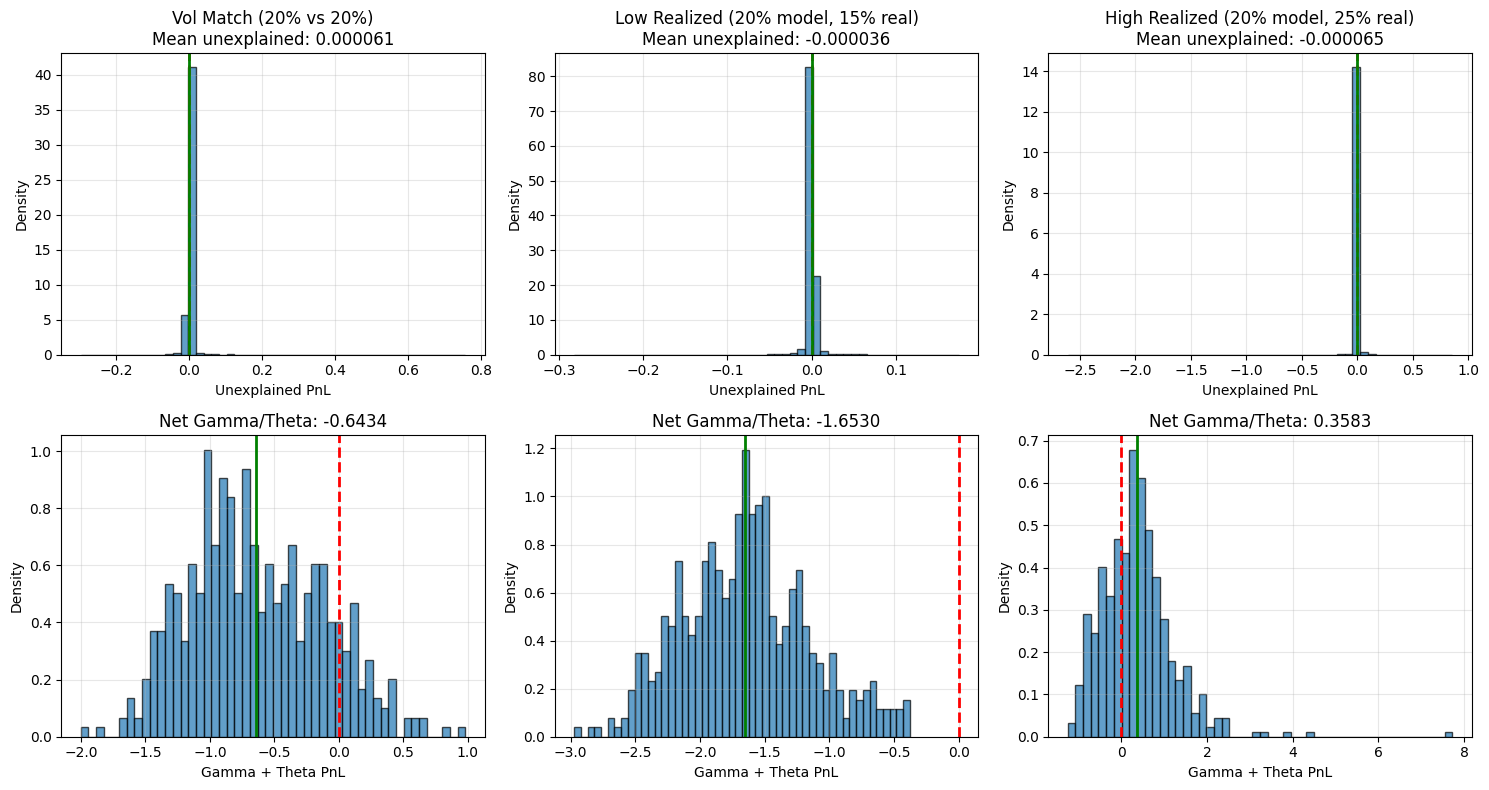


Summary Statistics:

Vol Match (20% vs 20%):
  Mean Gamma PnL:   1.96438
  Mean Theta PnL:  -2.60777
  Mean Net:        -0.64339
  Std Net:          0.51831

Low Realized (20% model, 15% real):
  Mean Gamma PnL:   1.25175
  Mean Theta PnL:  -2.90478
  Mean Net:        -1.65303
  Std Net:          0.48950

High Realized (20% model, 25% real):
  Mean Gamma PnL:   2.81122
  Mean Theta PnL:  -2.45292
  Mean Net:         0.35831
  Std Net:          0.84885


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, (name, data) in enumerate(results.items()):
    # Unexplained distribution
    ax = axes[0, idx]
    ax.hist(data['unexplained'], bins=50, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(0, color='r', linestyle='--', linewidth=2)
    mean_unexp = np.mean(data['unexplained'])
    ax.axvline(mean_unexp, color='g', linestyle='-', linewidth=2)
    ax.set_xlabel('Unexplained PnL')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nMean unexplained: {mean_unexp:.6f}')
    ax.grid(True, alpha=0.3)
    
    # Gamma-Theta net
    ax = axes[1, idx]
    net_gamma_theta = data['gamma_pnl'] + data['theta_pnl']
    ax.hist(net_gamma_theta, bins=50, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(0, color='r', linestyle='--', linewidth=2)
    mean_net = np.mean(net_gamma_theta)
    ax.axvline(mean_net, color='g', linestyle='-', linewidth=2)
    ax.set_xlabel('Gamma + Theta PnL')
    ax.set_ylabel('Density')
    ax.set_title(f'Net Gamma/Theta: {mean_net:.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print("="*70)
for name, data in results.items():
    net = data['gamma_pnl'] + data['theta_pnl']
    print(f"\n{name}:")
    print(f"  Mean Gamma PnL:  {np.mean(data['gamma_pnl']):8.5f}")
    print(f"  Mean Theta PnL:  {np.mean(data['theta_pnl']):8.5f}")
    print(f"  Mean Net:        {np.mean(net):8.5f}")
    print(f"  Std Net:         {np.std(net):8.5f}")

The results show the mechanics of volatility arbitrage:

- When realized matches implied: net gamma/theta PnL is roughly zero
- When realized < implied: short gamma is profitable (you collect more theta than you lose to gamma)
- When realized > implied: long gamma is profitable (gamma gains exceed theta decay)

This is how vol desks trade: forecast realized vol, compare to implied, and position accordingly. Delta-hedge to isolate the vol bet. The model doesn't need to be "correct"—it just needs to be good enough to isolate what you're betting on.

## 6. Summary

We covered the full chain from model to PnL:

1. Black-Scholes is really about hedging, not pricing. The formula gives the cost of replication.

2. Discrete hedging introduces gamma PnL. The hedging error scales as $O(1/\sqrt{n})$—more frequent rebalancing means less variance, but also more transaction costs.

3. PnL decomposes into Greek contributions. The unexplained residual tells you if your model is capturing reality.

4. Model mismatch creates systematic PnL. This is exploitable—it's the basis of volatility trading.

Black-Scholes survives not because it's "correct" but because the hedging framework is robust. Even when vol isn't constant, continuous delta-hedging with current implied vol gets you most of the way there.